# m-mode simulations for albatros

Spherical harmonics are the natural basis for imaging on a sphere. This notebook is an attempt to understand m-mode imaging and the various factors involved in interferometry on a sphere. In particular I'm trying to take a healpix map of diffuse flux and use spherical harmonics to image it with an interferometer instead of treating each pixel of the map as a discrete point source

### Visibilities

Visibilities are weighted integrals of the sky multiplied by the beam with a geometric phase term for a baseline, sampling a fourier mode on the sky

$$V_{ij} = \int I(\theta, \phi) B(\theta, \phi) e^{-2\pi i\mathbf{u}_{ij} \cdot \mathbf{s}} d\Omega$$

where, 
- $\mathbf{u}_{ij}$ is the baseline vector between antennas $i$, $j$ in wavelenghts
- $e^{-2\pi i\mathbf{u}_{ij} \cdot \mathbf{s}}$ represents the interferometer’s Fourier sampling of the sky
- $\mathbf{s}$ is a direction in the sky

We can rewrite this as a function of sky intensity $I(\theta, \phi)$, and a beam transfer function $\mathbb{B}(\theta, \phi)=B(\theta, \phi) e^{-2\pi i\mathbf{u}_{ij} \cdot \mathbf{s}}$, which captures both the primary beam pattern $B(\theta, \phi)$, and the fringe pattern $e^{-2\pi i\mathbf{u}_{ij} \cdot \mathbf{s}}$.

$$V_{ij} = \int I(\theta, \phi) \mathbb{B}(\theta, \phi) d\Omega$$

### Spherical Harmonic Transform of the Sky and Beam Transfer Function

- Suppose you have a sky map $I(\theta, \phi)$ and a beam transfer function $\mathbb{B}(\theta, \phi)$
- Both can be decomposed into spherical harmonics $Y_{lm}(\theta, \phi):$

$$I(\theta, \phi) = \sum_{lm}a^{sky}_{lm}Y_{lm}(\theta, \phi),$$

$$\mathbb{B}(\theta, \phi) = \sum_{lm}a^{beam}_{lm}Y_{lm}(\theta, \phi),$$

where $a^{sky}_{lm}$, $a^{beam}_{lm}$ are the spherical harmonic coefficients of the sky and the beam respectively

Since spherical harmonics are orthogonal

$$q_m = \sum_{l}a^{sky}_{lm} \cdot a^{beam}_{lm}$$

We can either think of the sky rotating over a stationary beam, or the earth scanning the beam across a starionary sky. This can be achieved by multiplying $q_m$ by a factor of $e^{im\Phi}$, where $\Phi$ is the sidereal azimuthal angle. So the visibility as a function of time (or rotation angle $\Phi$) becomes:

$$V(\Phi) = \sum_m e^{im\Phi} q_m$$

This represents the rotationally averaged visibilities

In [1]:
from typing import Union, Dict, Tuple
from numpy.typing import NDArray

import numpy as np
import healpy as hp

import cmasher as cmr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm, ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

import astropy.units as u
import astropy.constants as c
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, ICRS, Longitude
from scipy.interpolate import RectBivariateSpline

from tqdm.notebook import tqdm
from pyuvdata import utils
from pyuvdata import UVData, UVBeam
from pygdsm import GlobalSkyModel
from skyfield.api import load, wgs84

nice_fonts = {
    # Use LaTeX to write all text
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts}",
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "font.size": 8,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 6,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

plt.rcParams.update(nice_fonts)

## Read OWRO LWA Beam model

Courtesy of Nivedita Mahesh via Ruby Byrne. I suspect this is a FEKO model, with MRO soil and a 3x3m groundscreen

In [2]:
def load_beam(beam_path: str, freq_array: np.ndarray, beam_type: str = "efield") -> UVBeam:
    """
    Load a UVBeam object from a FITS file, check if the given frequency range is within 
    the beam's frequency range, and interpolate the beam to the new frequencies.

    Parameters
    ----------
    beam_path : str
        Path to the FITS beam file.
    freq_array : np.ndarray
        Array of new frequencies (in Hz) for interpolation.
    beam_type : str, optional
        The type of beam to return. Options are:
        - "efield" (default): Return the electric field beam (complex).
        - "power": Convert the beam to power (XX, YY, XY, YX).
        - "pstokes": Convert the beam to pseudo-Stokes (pI, pQ, pU, pV).

    Returns
    -------
    UVBeam
        A new UVBeam object interpolated to the given frequency array.

    Raises
    ------
    ValueError
        If the given frequency range is outside the original beam frequency range.
    ValueError
        If an invalid `beam_type` is provided.
    """

    # Load the beam from file
    beam = UVBeam.from_file(beam_path)

    # Convert beam type
    if beam_type == "power":
        beam.efield_to_power()
    elif beam_type == "pstokes":
        beam.efield_to_pstokes()
    elif beam_type != "efield":
        raise ValueError(
            f"Invalid beam type '{beam_type}'. Must be one of 'efield', 'power', or 'pstokes'."
        )

    # Zero out beam values for zenith angles > 90 degrees
    beam.data_array[..., beam.axis2_array > np.pi / 2, :] = 0

    # Normalize the beam to its peak value
    beam.peak_normalize()

    # Extract the original frequency range
    orig_freqs = beam.freq_array.squeeze()

    # Check if requested frequencies are within the original range
    if np.min(freq_array) < np.min(orig_freqs) or np.max(freq_array) > np.max(orig_freqs):
        raise ValueError(
            f"Requested frequency range [{np.min(freq_array)/1e6:.2f} MHz, {np.max(freq_array)/1e6:.2f} MHz] "
            f"is outside the beam's range [{np.min(orig_freqs)/1e6:.2f} MHz, {np.max(orig_freqs)/1e6:.2f} MHz]."
        )

    # Interpolate beam to the given frequencies
    new_beam = beam.interp(freq_array=freq_array, freq_interp_kind='cubic', new_object=True)

    return new_beam

In [3]:
def interpolate_and_rotate_beam(
    beam: UVBeam, target_nside: int, location: EarthLocation
) -> np.ndarray:
    """
    Interpolates a UVBeam object onto a HEALPix grid and rotates it to the given Earth location.

    Parameters
    ----------
    beam : UVBeam
        The UVBeam object containing the beam data.
    target_nside : int
        The desired HEALPix Nside resolution for the output beam.
    location : EarthLocation
        The Earth location of the observatory, used for rotating the beam.

    Returns
    -------
    np.ndarray
        A NumPy array of shape `(1, Npols, Nfreqs, Npix)` containing the interpolated 
        and rotated beam in HEALPix format.

    Notes
    -----
    - This function uses `RectBivariateSpline` for interpolation in azimuth/zenith angle.
    - The beam is rotated to the observatory's latitude.
    - HEALPix ordering is RING by default.
    """

    # Get HEALPix parameters
    npix = hp.nside2npix(target_nside)

    # Initialize output array
    use_beam = np.zeros((1, beam.Npols, beam.Nfreqs, npix), dtype=np.float64)

    # Zenith and azimuth angle grids from the beam
    za = beam.axis2_array  # Zenith angle (radians)
    az = beam.axis1_array  # Azimuth angle (radians)

    # Get HEALPix pixel angles
    theta, phi = hp.pix2ang(target_nside, np.arange(npix))

    # Convert HEALPix phi to beam's azimuth convention
    phi = Longitude((np.pi / 2 - phi) * u.rad).rad

    # Loop over polarizations and frequencies
    for p in range(beam.Npols):
        for f in range(beam.Nfreqs):
            beam_vals = beam.data_array[0, p, f]

            # Create 2D spline interpolator
            interp = RectBivariateSpline(za, az, beam_vals, kx=3, ky=3)

            # Interpolate beam onto HEALPix grid
            hpx_beam = interp(theta, phi, grid=False)

            # Convert interpolated beam to spherical harmonics (alm)
            alms = hp.map2alm(hpx_beam, use_pixel_weights=True)

            # Rotate the beam to match the observatory latitude
            hp.rotate_alm(alms, 0, np.pi / 2 - location.lat.rad, 0)

            # Convert back to a HEALPix map
            rotated_beam = hp.alm2map(alms, target_nside)

            # Store result
            use_beam[0, p, f] = rotated_beam

    return use_beam

In [4]:
def rotate_healpix_map_galactic_to_icrs(healpix_map: np.ndarray) -> np.ndarray:
    """
    Rotates a HEALPix map from Galactic (G) coordinates to Celestial (ICRS, C) coordinates.

    Parameters
    ----------
    healpix_map : np.ndarray
        Input HEALPix map in Galactic coordinates. If 1D, assumed to be (npix,).
        If 2D, assumed to be (N, npix), where N is the number of frequency channels.

    Returns
    -------
    np.ndarray
        Rotated HEALPix map in Celestial (ICRS) coordinates.
        If input is (npix,), returns (npix,). If input is (N, npix), returns (N, npix).
    """

    # Ensure healpix_map is at least 2D (N, npix)
    healpix_map = np.atleast_2d(healpix_map)  # Converts (npix,) -> (1, npix) if necessary

    # Determine nside automatically from the number of pixels
    nside = hp.npix2nside(healpix_map.shape[1])

    # Create a Rotator object to convert from Galactic (G) to Equatorial (C)
    rot = hp.rotator.Rotator(coord=["G", "C"], inv=True)

    # Get HEALPix pixel centers in Galactic coordinates
    theta_g, phi_g = hp.pix2ang(nside, np.arange(healpix_map.shape[1]))  # (θ, φ) in Galactic

    # Rotate the (theta, phi) coordinates from Galactic to Celestial
    theta_c, phi_c = rot(theta_g, phi_g)

    # Interpolate the old maps onto the new coordinates for each frequency
    rotated_map = np.array([hp.get_interp_val(freq_map, theta_c, phi_c) for freq_map in healpix_map])

    return rotated_map

In [5]:
def enu_to_eci_matrix(ha: float, lat: float) -> NDArray[np.float64]:
    """
    Compute the 3x3 transformation matrix to rotate East-North-Up (ENU) coordinates 
    to Earth-Centered Inertial (ECI) coordinates.

    This transformation is used to project local observer-centric ENU coordinates 
    at a given time and location to ECI coordinates, which are aligned with the celestial pole.

    In the ECI coordinate system:
    - (RA=0  deg, Dec=0  deg) corresponds to (1, 0, 0)
    - (RA=90 deg, Dec=0  deg) corresponds to (0, 1, 0)
    - (RA=0  deg, Dec=90 deg) corresponds to (0, 0, 1)

    Parameters
    ----------
    ha : float
        Hour angle (HA = LST - RA), in radians.

    lat : float
        Latitude of the observer, in radians.

    Returns
    -------
    np.ndarray
        3x3 numpy array representing the rotation matrix for the given HA and latitude.

    References
    ----------
    - `ESA Navipedia: Transformations between ECEF and ENU coordinates <https://gssc.esa.int/navipedia/index.php/Transformations_between_ECEF_and_ENU_coordinates>`_
    """

    return np.array([
        [-np.sin(ha), -np.cos(ha) * np.sin(lat), np.cos(ha) * np.cos(lat)],
        [ np.cos(ha), -np.sin(ha) * np.sin(lat), np.sin(ha) * np.cos(lat)],
        [         0.0,              np.cos(lat),              np.sin(lat)],
    ], dtype=np.float64)

In [6]:
# Read reference uvfits
uvd = UVData.from_file("../data/uvfits/albatros_sim_gsm_14MHz_24h.uvfits")
lat, lon, alt = uvd.telescope.location_lat_lon_alt_degrees

In [7]:
# Metadata
albatros = EarthLocation(lat=lat, lon=lon, height=alt)

# Target nside
nside=2048
l_max = (3*nside)-1
n_m = (2 * l_max) + 1
sidereal = 86164.0905
d_sidereal = sidereal / n_m

In [8]:
beam_path = "../data/beams/LWA_10to100_MROsoil_efields.fits"
beam = load_beam(beam_path, freq_array=uvd.freq_array, beam_type='pstokes')
beam_halfsky_altaz = beam.select(axis2_inds=np.where(beam.axis2_array <= np.pi/2)[0], inplace=False)
beam_hpx = interpolate_and_rotate_beam(beam, nside, albatros)

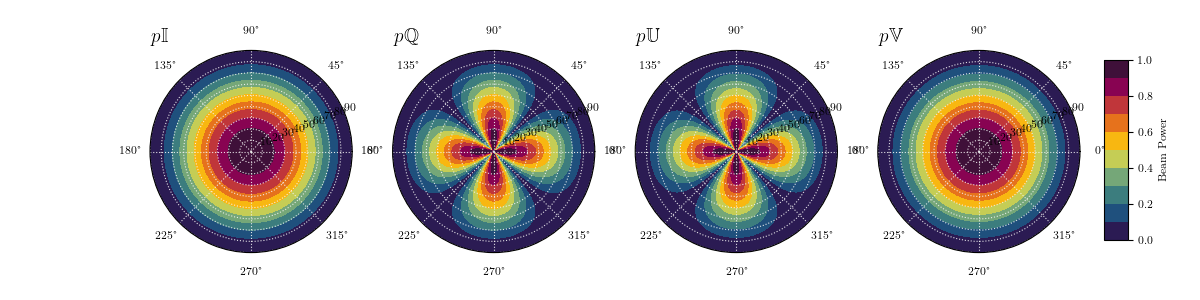

In [9]:
%matplotlib widget
# Plot beams

# Create mesh grid
az_array, za_array = np.meshgrid(
    beam_halfsky_altaz.axis1_array, np.rad2deg(beam_halfsky_altaz.axis2_array)
)

# Create figure with 4 subplots in a row
fig, axes = plt.subplots(
    1, 4, subplot_kw=dict(projection='polar'), figsize=(12, 3)
)

# Titles for each subplot
titles = [r"$p\mathbb{I}$", r"$p\mathbb{Q}$", r"$p\mathbb{U}$", r"$p\mathbb{V}$"]

for i, ax in enumerate(axes):
    ax.grid(True, ls=":", color="whitesmoke", alpha=0.9)

    # Plot contourf
    contourplot = ax.contourf(
        az_array,
        za_array,
        np.real(beam_halfsky_altaz.data_array[0, i, 0]),
        levels=11,
        cmap=cmr.pride,
    )

    # Set title for each subplot
    ax.set_title(titles[i], fontsize=14, loc='left')

# Add a single colorbar for all plots
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # Colorbar position
cbar = plt.colorbar(contourplot, cax=cbar_ax, label="Beam Power", orientation="vertical")

plt.show()

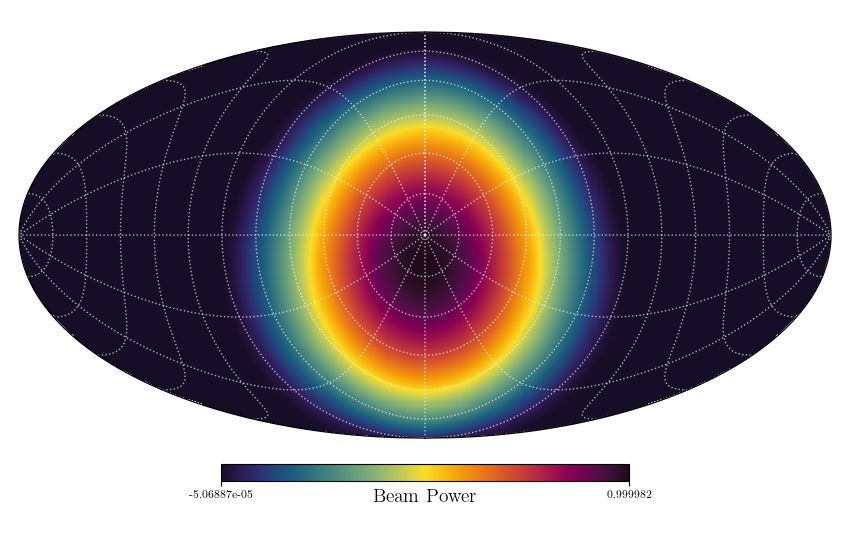

In [10]:
%matplotlib widget

# Define a colormap with 11 discrete colors
colors = cmr.pride(np.linspace(0, 1, 11))
cmap = ListedColormap(colors)

hp.mollview(
    beam_hpx[0, 0, 0],
    rot=(0, 90),
    # cmap=cmap,
    cmap=cmr.pride,
    cbar=True,
    unit='Beam Power',
    title="")

hp.visufunc.graticule(15, 360/12, ls=":", color="whitesmoke", alpha=0.7)
plt.show()

## PyGDSM

In [11]:
# This may produce artifacts - ud_grade is bad
gsm = GlobalSkyModel(freq_unit='MHz')
gsm_hpx = rotate_healpix_map_galactic_to_icrs(hp.pixelfunc.ud_grade(gsm.generate(uvd.freq_array/1e6), nside))

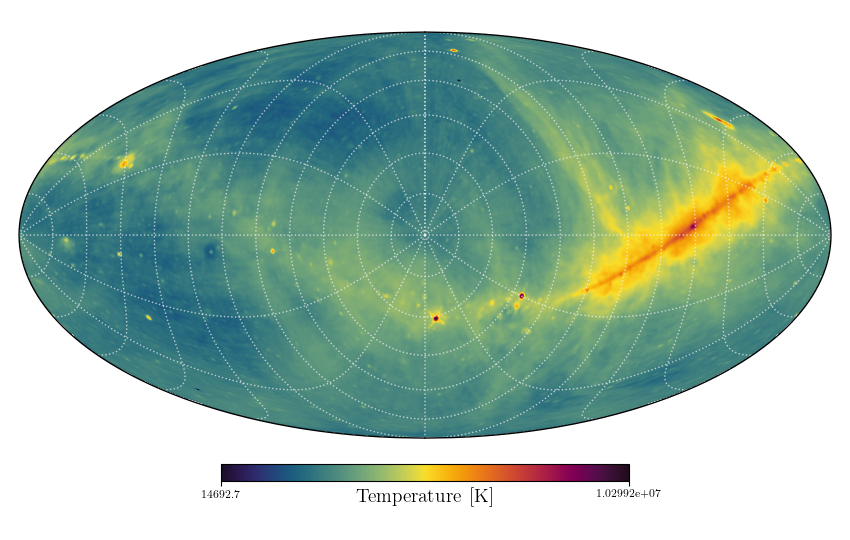

In [12]:
%matplotlib widget

hp.mollview(
    gsm_hpx[0],
    rot=(0, 90),
    cmap=cmr.pride,
    cbar=True,
    norm="log",
    unit='Temperature [K]',
    title="")

hp.visufunc.graticule(15, 360/12, ls=":", color="whitesmoke", alpha=0.7)
plt.show()

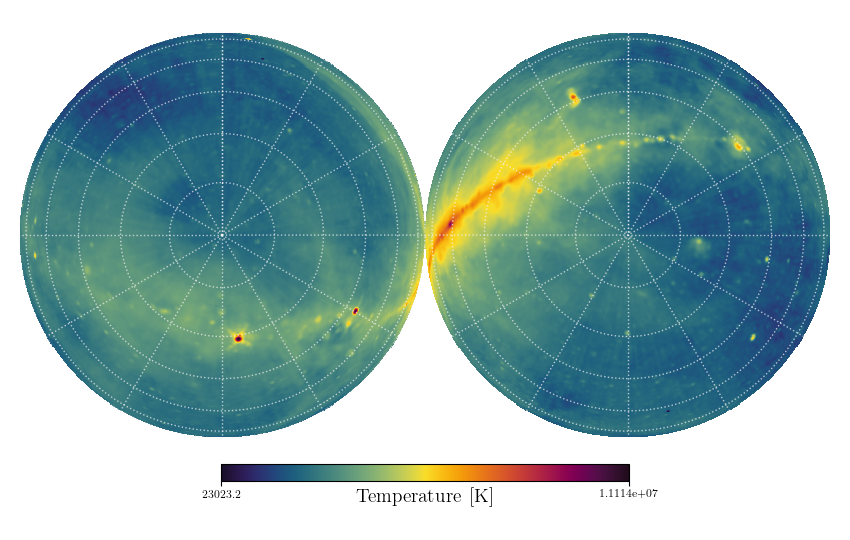

In [13]:
%matplotlib widget

hp.orthview(
    gsm_hpx[0],
    rot=[0, 90],
    cmap=cmr.pride,
    cbar=True,
    norm="log",
    unit='Temperature [K]',
    title="")

hp.visufunc.graticule(15, 360/12, ls=":", color="whitesmoke", alpha=0.7)
plt.show()

## Spherical Harmonic Decomposition of Complex Fields

We decompose a complex field into its real and imaginary parts:

$$C_{\ell m} = a_{\ell m} + i b_{\ell m}$$

We compute the power spectrum as:

$$|C_{\ell m}|^2 = C_{\ell m} C_{\ell m}^*$$

Expanding this:

$$|C_{\ell m}|^2 = (a_{\ell m} + i b_{\ell m}) (a_{\ell m}^* - i b_{\ell m}^*) = |a_{\ell m}|^2 + |b_{\ell m}|^2 + CT$$


where the last term $CT$ represents the cross power term:

$$ CT = i (a_{\ell m}^* b_{\ell m} - a_{\ell m} b_{\ell m}^*)$$

Looking at individual terms:

$$ a_{\ell m}^* b_{\ell m} = (a_r + i a_i)^*(b_r + i b_i) = (a_r - i a_i)(b_r + i b_i) = (a_r b_r + a_i b_i) + i(a_r b_i - a_i b_r)$$
$$ a_{\ell m} b_{\ell m}^* = (a_r + i a_i)(b_r + i b_i)^* = (a_r + i a_i)(b_r - i b_i) = (a_r b_r + a_i b_i) + i(a_i b_r - a_r b_i)$$

$$ \therefore CT = i \{ i(a_r b_i - a_i b_r) - i(a_i b_r - a_r b_i)\} = 2(a_i b_r - a_r b_i) = 2 \operatorname{Im}(a_{\ell m} b_{\ell m}^*)$$

$$ \therefore |C_{\ell m}|^2 = (a_{\ell m} + i b_{\ell m}) (a_{\ell m}^* - i b_{\ell m}^*) = |a_{\ell m}|^2 + |b_{\ell m}|^2 + 2 \operatorname{Im}(a_{\ell m} b_{\ell m}^*) $$


### For a Real-Valued Field
For a real-valued field, the spherical harmonic coefficients satisfy:

$$
a_{\ell, -m} = (-1)^m a_{\ell m}^*, \quad b_{\ell, -m} = (-1)^m b_{\ell m}^*
$$

which implies:

$$C_{\ell, -m} = a_{\ell, -m} + i b_{\ell, -m}$$


Expanding this:

$$|C_{\ell, -m}|^2 = (a_{\ell, -m} + i b_{\ell, -m}) (a_{\ell, -m}^* - i b_{\ell, -m}^*) = |a_{\ell m}|^2 + |b_{\ell m}|^2 + CT$$


where the last term $CT$ represents the cross power term:

$$ CT = i (a_{\ell m} b_{\ell m}^* - a_{\ell m}^* b_{\ell m})$$

$$ \therefore CT = i \{ i(a_i b_r - a_r b_i) - i(a_r b_i - a_i b_r)\} = 2(a_r b_i - a_i b_r) = 2 \operatorname{Im}(a_{\ell m}^* b_{\ell m})$$

$$ \therefore |C_{\ell, -m}|^2 = |a_{\ell m}|^2 + |b_{\ell m}|^2 + 2 \operatorname{Im}(a_{\ell m}^* b_{\ell m}) $$

In [14]:
def compute_m_mode_spectra(uvd: UVData, beam_hpx: np.ndarray, albatros: EarthLocation, nside: int) -> np.ndarray:
    """
    Compute the m-mode power spectra from interferometric visibilities.

    Parameters
    ----------
    uvd : UVData
        A UVData object containing antenna positions and visibility data.
    beam_hpx : np.ndarray
        HEALPix beam representation of shape (1, 1, Nfreqs, Npix).
    albatros : EarthLocation
        Location of the interferometer.
    nside : int
        HEALPix resolution parameter.

    Returns
    -------
    m_mode_spectra : np.ndarray
        The computed m-mode spectra of shape (Nbls, Nfreqs, 2 * ell_max + 1).
    """

    # Extract antenna positions in ENU coordinates and their indices
    enu_antpos, antenna_numbers = uvd.get_ENU_antpos()
    antpairs = uvd.get_antpairs()

    # Convert ENU antenna positions to Earth-Centered Inertial (ECI) at LST=0
    enu_to_eci = enu_to_eci_matrix(ha=0, lat=albatros.lat.rad)
    eci_antpos = (enu_to_eci @ enu_antpos.T).T  # Shape: (Nants, 3)
    eci_antpos_dict: Dict[int, np.ndarray] = dict(zip(antenna_numbers, eci_antpos))

    # Compute unit sky position vectors in HEALPix pixelization
    npix = hp.nside2npix(nside)
    n_hat = np.array(hp.pix2vec(nside, np.arange(npix)))  # Shape: (3, Npix)

    # Set up m-mode parameters
    ell_max = 3 * nside - 1  # Maximum spherical harmonic mode
    m_modes = np.arange(-ell_max, ell_max + 1)  # Full range of m-modes

    # Initialize output array for m-mode spectra
    m_mode_spectra = np.zeros((uvd.Nbls, uvd.Nfreqs, 2 * ell_max + 1), dtype=np.float64)

    # Iterate over all antenna pairs (baselines)
    for k, (ai, aj) in enumerate(tqdm(antpairs, desc=r"Processing Baselines", colour="#5E4FA1")):

        # Compute baseline vector in ECI coordinates
        bl_vec = eci_antpos_dict[aj] - eci_antpos_dict[ai]  # Shape: (3,)

        # Compute geometric delays (tau) for all sky pixels
        delays = bl_vec @ n_hat / c.c.si.value

        # Iterate over frequencies
        for f, freq in enumerate(uvd.freq_array.flatten()):

            # Compute Fourier phase factor (fringe pattern)
            fringe = np.exp(2j * np.pi * freq * delays)  # Shape: (Npix,)

            # Multiply beam with fringe pattern to get the beam transfer function
            beam_xfer_func = beam_hpx[0, 0, f] * fringe

            # Compute spherical harmonic coefficients separately for real & imaginary parts
            alm = hp.map2alm(beam_xfer_func.real, lmax=ell_max, use_pixel_weights=True)
            blm = hp.map2alm(beam_xfer_func.imag, lmax=ell_max, use_pixel_weights=True)

            # Compute m-mode power spectrum
            start = 0
            for m in range(ell_max + 1):
                pos_idx = np.argmin(np.abs(m - m_modes))
                neg_idx = np.argmin(np.abs(m + m_modes))
                
                # Get the indices corresponding to (l, m) values
                ell_inds = hp.sphtfunc.Alm.getidx(ell_max, np.arange(m, ell_max + 1), m)
                
                # Compute power spectra
                alm_sq = np.abs(alm[ell_inds]) ** 2
                blm_sq = np.abs(blm[ell_inds]) ** 2
                pos_cross_term = 2 * np.imag(alm[ell_inds] * blm[ell_inds].conj())
                neg_cross_term = 2 * np.imag(alm[ell_inds].conj() * blm[ell_inds])
                
                # Assign to positive and negative m-mode indices
                m_mode_spectra[k, f, pos_idx] = np.sum(alm_sq + blm_sq + pos_cross_term)
                m_mode_spectra[k, f, neg_idx] = np.sum(alm_sq + blm_sq + neg_cross_term)

                # Update starting index for next m
                start += ell_max - m + 1

    return m_mode_spectra

In [15]:
m_mode_spectra = compute_m_mode_spectra(uvd, beam_hpx, albatros, nside)

Processing Baselines:   0%|          | 0/21 [00:00<?, ?it/s]

In [16]:
# Set up m-mode parameters
ell_max = 3 * nside - 1  # Maximum spherical harmonic mode
m_modes = np.arange(-ell_max, ell_max + 1)  # Full range of m-modes

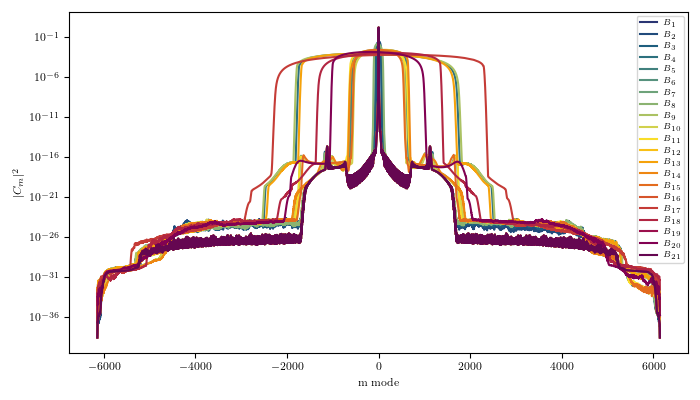

In [17]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(7, 4))

colors = cmr.pride(np.linspace(0.1, 0.9, 21))

for i in range(21):
    ax.plot(m_modes, m_mode_spectra[i, 0], color=colors[i], label=f"$B_{{{i+1}}}$")

ax.set_yscale('log')
ax.set_xlabel('m mode')
ax.set_ylabel('$|C_m|^2$')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Simulate m-modes

In [18]:
def simulate_mmodes(uvd: UVData, beam_hpx: np.ndarray, sky_hpx: np.ndarray, albatros: EarthLocation, nside: int) -> np.ndarray:
    """
    Compute the m-mode coefficients from interferometric visibilities.

    Parameters
    ----------
    uvd : UVData
        A UVData object containing antenna positions and visibility data.
    beam_hpx : np.ndarray
        HEALPix beam representation of shape (1, 1, Nfreqs, Npix).
    sky_hpx : np.ndarray
        HEALPix sky intensity map of shape (Nfreqs, Npix).
    albatros : EarthLocation
        Location of the interferometer.
    nside : int
        HEALPix resolution parameter.

    Returns
    -------
    q_m : np.ndarray
        The computed m-mode coefficients of shape (Nbls, Nfreqs, 2 * ell_max + 1).
    beam_transfer_hpx : np.ndarray
        The beam transfer function of shape (Nbls, Nfreqs, Npix).
    """

    # Extract antenna positions in ENU coordinates and their indices
    enu_antpos, antenna_numbers = uvd.get_ENU_antpos()
    antpairs = uvd.get_antpairs()

    # Convert ENU antenna positions to Earth-Centered Inertial (ECI) at LST=0
    enu_to_eci = enu_to_eci_matrix(ha=0, lat=albatros.lat.rad)
    eci_antpos = (enu_to_eci @ enu_antpos.T).T  # Shape: (Nants, 3)
    eci_antpos_dict: Dict[int, np.ndarray] = dict(zip(antenna_numbers, eci_antpos))

    # Compute unit sky position vectors in HEALPix pixelization
    npix = hp.nside2npix(nside)
    n_hat = np.array(hp.pix2vec(nside, np.arange(npix)))  # Shape: (3, Npix)

    # Set up m-mode parameters
    ell_max = 3 * nside - 1  # Maximum spherical harmonic mode
    m_modes = np.arange(-ell_max, ell_max + 1)  # Full range of m-modes

    # Initialize output array for m-mode spectra
    q_m = np.zeros((uvd.Nbls, uvd.Nfreqs, 2 * ell_max + 1), dtype=np.complex128)
    beam_transfer_hpx = np.zeros((uvd.Nbls, uvd.Nfreqs, hp.nside2npix(nside)), dtype=np.complex128)

    # Iterate over all antenna pairs (baselines)
    for k, (ai, aj) in enumerate(tqdm(antpairs, desc=r"Processing Baselines", colour="#5E4FA1")):

        # Compute baseline vector in ECI coordinates
        bl_vec = eci_antpos_dict[aj] - eci_antpos_dict[ai]  # Shape: (3,)

        # Compute geometric delays (tau) for all sky pixels
        delays = bl_vec @ n_hat / c.c.si.value

        # Iterate over frequencies
        for f, freq in enumerate(uvd.freq_array.flatten()):

            # Compute Fourier phase factor (fringe pattern)
            fringe = np.exp(2j * np.pi * freq * delays)  # Shape: (Npix,)

            # Multiply beam with fringe pattern to get the beam transfer function
            beam_xfer_func = beam_hpx[0, 0, f] * fringe

            # Compute spherical harmonic coefficients separately for real & imaginary parts
            alm = hp.map2alm(beam_xfer_func.real, lmax=ell_max, use_pixel_weights=True)
            blm = hp.map2alm(beam_xfer_func.imag, lmax=ell_max, use_pixel_weights=True)
            slm = hp.map2alm(sky_hpx[f], lmax=ell_max, use_pixel_weights=True)
            
            beam_transfer_hpx[k, f] = beam_xfer_func

            # Compute m-mode power spectrum
            start = 0
            for m in range(ell_max + 1):
                pos_idx = np.argmin(np.abs(m - m_modes))
                neg_idx = np.argmin(np.abs(m + m_modes))
                
                # Get the indices corresponding to (l, m) values
                ell_inds = hp.sphtfunc.Alm.getidx(ell_max, np.arange(m, ell_max + 1), m)

                alm_ell = alm[ell_inds]
                blm_ell = blm[ell_inds]
                slm_ell = slm[ell_inds]
            
                
                # Compute m_modes
                q_m[k, f, pos_idx] = np.sum(slm_ell*alm_ell + 1j*slm_ell*blm_ell)
                q_m[k, f, neg_idx] = np.sum(slm_ell.conj()*alm_ell.conj() + 1j*slm_ell.conj()*blm_ell.conj())

                # Update starting index for next m
                start += ell_max - m + 1

    return q_m, beam_transfer_hpx

In [19]:
q_m, beam_transfer_hpx = simulate_mmodes(uvd, beam_hpx, gsm_hpx, albatros, nside)

Processing Baselines:   0%|          | 0/21 [00:00<?, ?it/s]

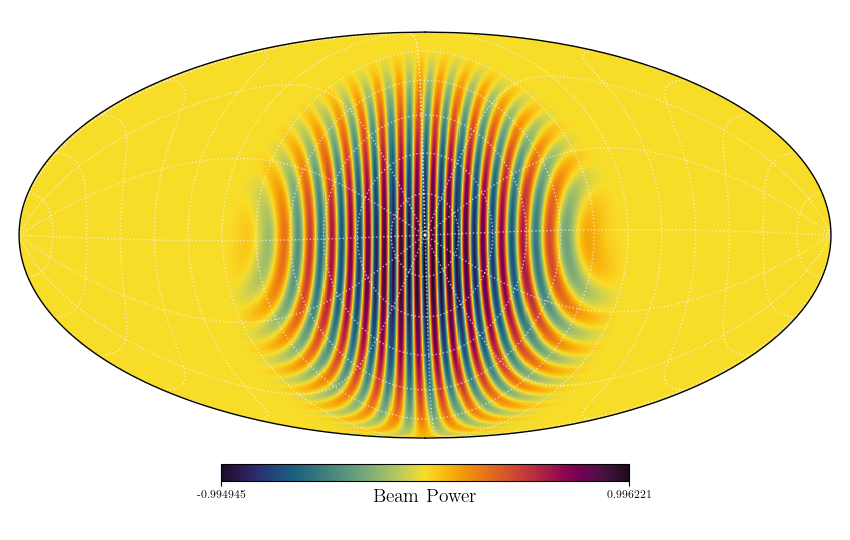

In [30]:
%matplotlib widget

hp.mollview(
    beam_transfer_hpx[1, 0].real,
    rot=(2, 90),
    cmap=cmr.pride,
    cbar=True,
    unit='Beam Power',
    title="")

hp.visufunc.graticule(15, 360/12, ls=":", color="whitesmoke", alpha=0.7)
plt.show()

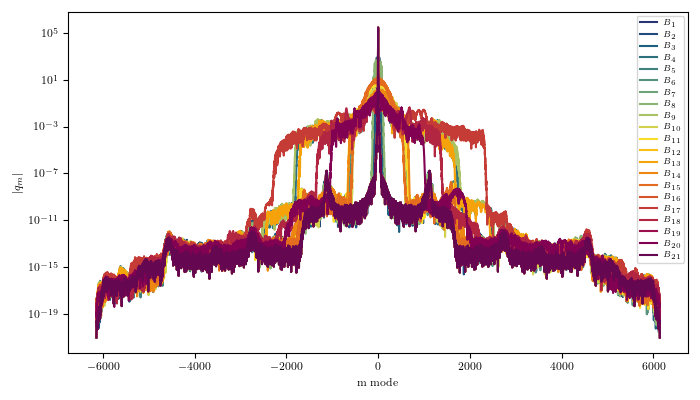

In [21]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(7, 4))

colors = cmr.pride(np.linspace(0.1, 0.9, 21))

for i in range(21):
    ax.plot(m_modes, np.abs(q_m[i, 0]), color=colors[i], label=f"$B_{{{i+1}}}$")

# ax.plot(m_modes, np.abs(q_m[1, 0]), color=colors[i], label=f"$B_{{{i+1}}}$")

ax.set_yscale('log')
ax.set_xlabel('m mode')
ax.set_ylabel('$|q_m|$')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [38]:
m_uni = np.sort(np.unique(m_modes))
n_m = m_uni[-1] - m_uni[0] + 1
d_m = m_uni[1] - m_uni[0]
phi = np.fft.fftshift(np.fft.fftfreq(n_m, d_m) * 2 * np.pi) 
d_t = np.fft.fftshift(np.fft.fftfreq(n_m, d_m) * sidereal)/(3600)
v_phi = np.fft.ifft(np.fft.ifftshift(q_m[2, 0]))

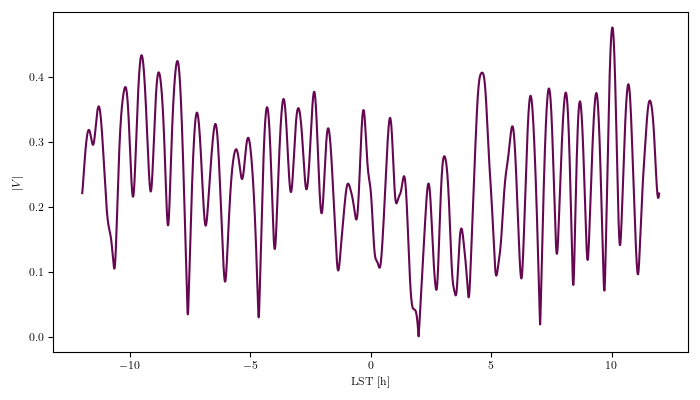

In [41]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(7, 4))

colors = cmr.pride(np.linspace(0.1, 0.9, 21))

ax.plot(d_t, np.abs(v_phi), color=colors[i])

# ax.set_yscale('log')
ax.set_xlabel('LST [h]')
ax.set_ylabel('$|V|$')

plt.tight_layout()
plt.show()